### Que1.-
In this dataset you have to predict that whether we have to give ATTORNEY to the clients or not (0=Yes, 1=No) based on below factors.
- CLMAGE - Age of Client
- CLMSEX - Sex of client (0=Male, 1= Female)
- SEATBELT - Whether client has Seatbelt or not (0=Yes, 1=No)
- CLMINSUR - Whether Client give Insurance or not (0=Yes, 1=No)
- LOSS - Loss that client faced

Prepare model by using Decision Tree, Random Forest & Also calculate Accuracy by confusion matrix, Calculate accuracy score, precision score, recall score, f1 score.

Dataset : Claimants.csv


### import required packages

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [111]:
df = pd.read_csv('./claimants.csv')
df.head(2)

,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0,0.0,1.0,0.0,50.0,34.940
1,1,1.0,0.0,0.0,18.0,0.891


### exploratory data analysis

In [112]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ATTORNEY  1340 non-null   int64  
 1   CLMSEX    1328 non-null   float64
 2   CLMINSUR  1299 non-null   float64
 3   SEATBELT  1292 non-null   float64
 4   CLMAGE    1151 non-null   float64
 5   LOSS      1340 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 62.9 KB


In [113]:
df.isna().sum()

ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [114]:
df.dropna(inplace = True)

In [115]:
df.isna().sum()

ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

In [116]:
df.info()

<class 'pandas.DataFrame'>
Index: 1096 entries, 0 to 1339
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ATTORNEY  1096 non-null   int64  
 1   CLMSEX    1096 non-null   float64
 2   CLMINSUR  1096 non-null   float64
 3   SEATBELT  1096 non-null   float64
 4   CLMAGE    1096 non-null   float64
 5   LOSS      1096 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 59.9 KB


In [117]:
df.corr()

,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
ATTORNEY,1.000000,0.097475,0.084609,-0.060795,0.001132,-0.225769
CLMSEX,0.097475,1.000000,0.058164,-0.017814,-0.017942,-0.029742
CLMINSUR,0.084609,0.058164,1.000000,0.021217,0.048166,0.019502
SEATBELT,-0.060795,-0.017814,0.021217,1.000000,-0.028343,0.131182
CLMAGE,0.001132,-0.017942,0.048166,-0.028343,1.000000,0.065513
LOSS,-0.225769,-0.029742,0.019502,0.131182,0.065513,1.000000


In [118]:
#  ckeck if dataset is balanced or not
df['ATTORNEY'].value_counts()

ATTORNEY
0    578
1    518
Name: count, dtype: int64

### split the data

In [119]:
x = df.drop('ATTORNEY', axis = 1)
y = df['ATTORNEY']

In [120]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y , train_size= 0.8, random_state=42)

### create and train the model

In [130]:
def decision_tree():
    from sklearn.tree import DecisionTreeClassifier

    # create and train the model
    model = DecisionTreeClassifier(max_depth=3)
    model.fit(x_train,y_train)

    return model

In [131]:
def random_forest():
    from sklearn.ensemble import RandomForestClassifier

    #  create and train the model
    model = RandomForestClassifier(n_estimators=20, max_depth=3)
    model.fit(x_train,y_train)

    return model

### evaluate model

In [132]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_models(model, model_name, x, y):

    y_pred = model.predict(x)

    accuracy = accuracy_score(y,y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    return model_name, accuracy, precision, recall, f1

In [133]:
models = [
    {"model_name": "Decision Tree", "model": decision_tree()},
    {"model_name": "Random Forest", "model": random_forest()},
]


In [134]:
metrics_train = []

for model_info in models:
    status = evaluate_models(model_info['model'], model_info['model_name'], x_train, y_train)
    metrics_train.append(status)
metrics_train_df = pd.DataFrame(metrics_train, columns= ['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1 Score'] )
metrics_train_df

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.751142,0.745501,0.709046,0.726817
1,Random Forest,0.743151,0.730000,0.713936,0.721879


In [135]:
metrics_test = []

for model_info in models:
    status = evaluate_models(model_info['model'], model_info['model_name'], x_test, y_test)

    metrics_test.append(status)

metrics_test_df  = pd.DataFrame(metrics_test, columns = ['Algorithm','Accuracy','Precision','Recall','F1 Score'])
metrics_test_df

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.677273,0.711111,0.587156,0.643216
1,Random Forest,0.681818,0.714286,0.596330,0.650000


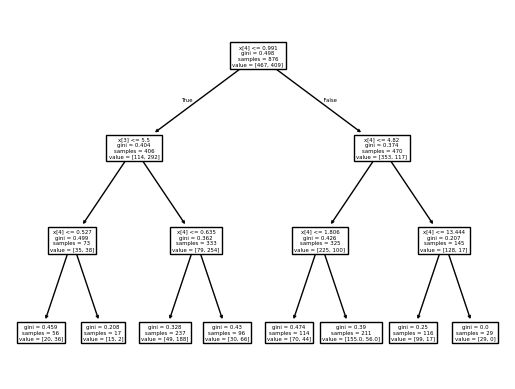

In [136]:
from sklearn.tree import plot_tree

_ = plot_tree(models[0]['model'])

### find the optimal solution fro the Decision Tree hyper-parameter

In [128]:
from sklearn.model_selection import GridSearchCV

parameter = {
    'max_depth': [3, 5, 7, 9]
}
grid_search = GridSearchCV(models[0]['model'], parameter)

grid_search.fit(x_train, y_train)

grid_search.best_params_

{'max_depth': 3}

### find the optimal solution for the Random Forest hyper-parameter

In [129]:
from sklearn.model_selection import GridSearchCV

parameter = {
    'n_estimators': [10, 15, 20],
    'max_depth': [3, 5, 7, 9]
}
grid_search = GridSearchCV(models[1]['model'], parameter)

grid_search.fit(x_train, y_train)

grid_search.best_params_

{'max_depth': 3, 'n_estimators': 20}

### Que2.-

The model's main purpose is to predict the 10-year risk of Coronary Heart Disease (CHD). CHD is a disease of the blood vessels supplying the heart. Heart disease has been the leading cause of death worldwide since 1921. In 2008, 7.3 million people died from CHD. 
The classification goal is to predict whether the patient has 10-year risk of future coronary heart disease (CHD).The dataset provides the patients’ information. It includes over 4,000 records and 15 attributes.
Variables
- Sex: male or female(0=female, 1=male)
- Age: Age of the patient
- education: Some high school (1), high school/GED (2), some college/vocational school (3), college (4)
- Current Smoker: whether or not the patient is a current smoker (0=No, 1=Yes)
- Cigs Per Day: the number of cigarettes that the person smoked on average in one day
- BP Meds: whether or not the patient was on blood pressure medication 
- Prevalent Stroke: whether or not the patient had previously had a stroke (0=No, 1=Yes)
- Prevalent Hyp: whether or not the patient was hypertensive (0=No, 1=Yes)
- Diabetes: whether or not the patient had diabetes (0=No, 1=Yes)
- Tot Chol: total cholesterol level
- Sys BP: systolic blood pressure 
- Dia BP: diastolic blood pressure
- BMI: Body Mass Index
- Heart Rate: heart rate
- Glucose: glucose level

Prepare model by using logistic regression Decision Tree, Random Forest.

Also calculate Accuracy by confusion matrix, Calculate accuracy score, precision score, recall score, f1 score.

Datasets : framingham.csv 

In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [156]:
df = pd.read_csv('./framingham.csv')
df.head(2)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0


### exploratory data analysis

In [157]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [158]:
df.isna().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [159]:
df.dropna(inplace = True)

In [160]:
df.info()

<class 'pandas.DataFrame'>
Index: 3658 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             3658 non-null   int64  
 1   age              3658 non-null   int64  
 2   education        3658 non-null   float64
 3   currentSmoker    3658 non-null   int64  
 4   cigsPerDay       3658 non-null   float64
 5   BPMeds           3658 non-null   float64
 6   prevalentStroke  3658 non-null   int64  
 7   prevalentHyp     3658 non-null   int64  
 8   diabetes         3658 non-null   int64  
 9   totChol          3658 non-null   float64
 10  sysBP            3658 non-null   float64
 11  diaBP            3658 non-null   float64
 12  BMI              3658 non-null   float64
 13  heartRate        3658 non-null   float64
 14  glucose          3658 non-null   float64
 15  TenYearCHD       3658 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 485.8 KB


### split the data

In [161]:
x = df.drop('TenYearCHD', axis= 1)
y = df['TenYearCHD']

In [162]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size= 0.8, random_state = 42)

### create and train the model

In [163]:
def logistic_regression():
    from sklearn.linear_model import LogisticRegressionCV

    # create and build the model

    model = LogisticRegressionCV()
    model.fit(x_train, y_train)

    return model

In [171]:
def decision_tree():
    from sklearn.tree import DecisionTreeClassifier

    # create and train the model

    model = DecisionTreeClassifier(max_depth=5)
    model.fit(x_train, y_train)

    return model

In [172]:
def random_forest():
    from sklearn.ensemble import RandomForestClassifier

    # create and train the model
    model = RandomForestClassifier()
    model.fit(x_train, y_train)

    return model

In [173]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def evaluate_models(model, model_name, x, y):

    y_pred = model.predict(x)

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    return model_name, accuracy, precision, recall, f1
    

In [174]:
models = [
    {"model_name": "Logistic Regression", "model": logistic_regression()},
    {"model_name": "Decision Tree", "model": decision_tree()},
    {"model_name": "Random Forest", "model": random_forest()} 
]

C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.w

In [175]:
metrics_train = []

for model_info in models:
    status = evaluate_models(model_info['model'], model_info['model_name'], x_train, y_train)

    metrics_train.append(status)

metrics_train_df = pd.DataFrame(metrics_train, columns = ['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
metrics_test_df

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.844262,1.000000,0.065574,0.123077
1,Decision Tree,0.719945,0.173228,0.180328,0.176707
2,Random Forest,0.837432,0.666667,0.049180,0.091603


In [176]:
metrics_test = []

for model_info in models:
    status = evaluate_models(model_info['model'], model_info['model_name'], x_test, y_test)

    metrics_test.append(status)

metrics_test_df = pd.DataFrame(metrics_test, columns = ['Algorithm','Accuracy', 'Precision', 'Recall', 'F1 Score'])
metrics_test_df

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.844262,1.000000,0.065574,0.123077
1,Decision Tree,0.830601,0.428571,0.049180,0.088235
2,Random Forest,0.837432,0.714286,0.040984,0.077519


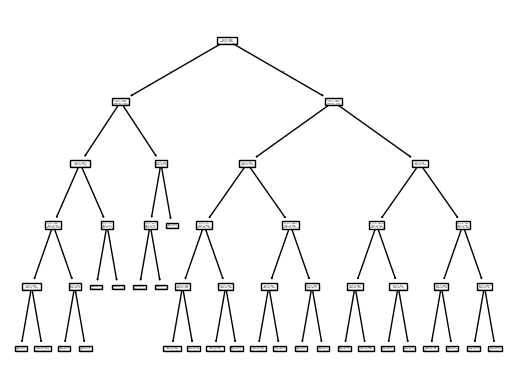

In [177]:
from sklearn.tree import plot_tree

_ = plot_tree(models[1]['model'])

### find the optimal values for Decision Tree and RandomForest for hyper-tuning

In [182]:
from sklearn.model_selection import GridSearchCV

parameter = {"max_depth" : [3, 5, 8]}

grid_search = GridSearchCV(models[1]['model'], parameter )
grid_search.fit(x_train, y_train)

grid_search.best_params_

{'max_depth': 3}

In [184]:
from sklearn.model_selection import GridSearchCV

parameter = {
    "n_estimators": [10, 15, 20],
    "max_depth" : [3, 5, 6, 9]
}

grid_search = GridSearchCV(models[2]['model'], parameter)

grid_search.fit(x_train, y_train)
grid_search.best_params_

{'max_depth': 3, 'n_estimators': 20}

### Que.3 -

Prepare a model for glass classification using Decision Tree, Random Forest.
Also calculate Accuracy by confusion matrix, Calculate accuracy score, precision score, recall score, f1 score.
Data Description:
- RI : refractive index
- Na: Sodium (unit measurement: weight percent in corresponding oxide, as are attributes 4-10)
- Mg: Magnesium
- AI: Aluminum
- Si: Silicon
- K:Potassium
- Ca: Calcium
- Ba: Barium
- Fe: Iron
- Type: Type of glass: (class attribute)
1 -- building_windows_float_processed
 2 --building_windows_non_float_processed
 3 --vehicle_windows_float_processed
 4 --vehicle_windows_non_float_processed (none in this database)
 5 --containers
 6 --tableware
 7 --headlamps

Dataset : Glass.csv


In [185]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [186]:
df = pd.read_csv('./glass.csv')
df.head(2)

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1


### exploratory data analysis

In [187]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [188]:
df.isna().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [189]:
df.corr()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
RI,1.000000,-0.191885,-0.122274,-0.407326,-0.542052,-0.289833,0.810403,-0.000386,0.143010,-0.164237
Na,-0.191885,1.000000,-0.273732,0.156794,-0.069809,-0.266087,-0.275442,0.326603,-0.241346,0.502898
Mg,-0.122274,-0.273732,1.000000,-0.481799,-0.165927,0.005396,-0.443750,-0.492262,0.083060,-0.744993
Al,-0.407326,0.156794,-0.481799,1.000000,-0.005524,0.325958,-0.259592,0.479404,-0.074402,0.598829
Si,-0.542052,-0.069809,-0.165927,-0.005524,1.000000,-0.193331,-0.208732,-0.102151,-0.094201,0.151565
K,-0.289833,-0.266087,0.005396,0.325958,-0.193331,1.000000,-0.317836,-0.042618,-0.007719,-0.010054
Ca,0.810403,-0.275442,-0.443750,-0.259592,-0.208732,-0.317836,1.000000,-0.112841,0.124968,0.000952
Ba,-0.000386,0.326603,-0.492262,0.479404,-0.102151,-0.042618,-0.112841,1.000000,-0.058692,0.575161
Fe,0.143010,-0.241346,0.083060,-0.074402,-0.094201,-0.007719,0.124968,-0.058692,1.000000,-0.188278
Type,-0.164237,0.502898,-0.744993,0.598829,0.151565,-0.010054,0.000952,0.575161,-0.188278,1.000000


In [190]:
df.drop(['K','Ca'], axis =1, inplace = True)

In [191]:
df.columns

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'Ba', 'Fe', 'Type'], dtype='str')

### split the data into x and y

In [192]:
x = df.drop('Type', axis =1)
y = df['Type']

In [193]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size= 0.8, random_state=42)

### create and train the model

In [214]:
def decision_tree():
    from sklearn.tree import DecisionTreeClassifier

    # create and train the model

    model = DecisionTreeClassifier(max_depth=6)

    model.fit(x_train, y_train)

    return model

In [217]:
def random_forest():
    from sklearn.ensemble import RandomForestClassifier

    # create and train the model

    model = RandomForestClassifier(max_depth = 8, n_estimators= 20)

    model.fit(x_train, y_train)

    return model

### evaluation of models

In [218]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, model_name, x , y):

    y_pred = model.predict(x)

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, average='weighted')
    recall = recall_score(y, y_pred, average='weighted')
    f1 = f1_score(y, y_pred, average = 'weighted')

    return model_name, accuracy, precision, recall, f1

In [219]:
models = [
    {"model_name": "Decision Tree", "model": decision_tree()},
    {"model_name": "Random Forest", "model": random_forest()}
]

In [220]:
metrics_train = []

for model_info in models:
    status = evaluate_model(model_info['model'], model_info['model_name'], x_train, y_train)

    metrics_train.append(status)

metrics_train_df = pd.DataFrame(metrics_train, columns = ['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
metrics_train_df

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.859649,0.866902,0.859649,0.855552
1,Random Forest,0.982456,0.983305,0.982456,0.982152


In [221]:
metrics_test = []

for model_info in models:
    status = evaluate_model(model_info['model'], model_info['model_name'], x_test, y_test)

    metrics_test.append(status)

metrics_test_df = pd.DataFrame(metrics_test, columns = ['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
metrics_test_df

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.744186,0.787468,0.744186,0.737100
1,Random Forest,0.790698,0.801587,0.790698,0.779575


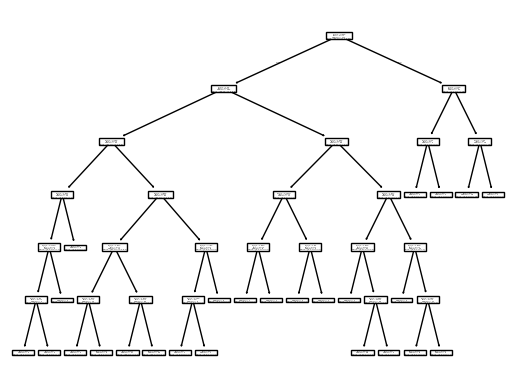

In [222]:
from sklearn.tree import plot_tree
_ = plot_tree(models[0]['model'])

### Find the optimal values for Decision Tree and Random Forest for hyper-parameter

In [223]:
from sklearn.model_selection import GridSearchCV
parameter = {
    "max_depth" : [3, 5, 6, 9]
}
grid_search = GridSearchCV(models[0]['model'], parameter)
grid_search.fit(x_train, y_train)
grid_search.best_params_

{'max_depth': 5}

In [224]:
from sklearn.model_selection import GridSearchCV
parameters = {
    "n_estimators": [10, 15, 20],
    "max_depth": [3, 5, 8,6]
}
grid_search = GridSearchCV(models[1]['model'], parameters)
grid_search.fit(x_train, y_train)
grid_search.best_params_

{'max_depth': 8, 'n_estimators': 20}

### Que.4 

Implement a Decision Tree, Random Forest model to classify the type of animals in the zoo in to different categories.
Also calculate Accuracy by confusion matrix, Calculate accuracy score, precision score, recall score, f1 score.

Dataset : Zoo.csv


In [225]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [226]:
df = pd.read_csv('./Zoo.csv')
df.head(2)

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1


### exploratory data analysis

In [227]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   hair      101 non-null    int64
 1   feathers  101 non-null    int64
 2   eggs      101 non-null    int64
 3   milk      101 non-null    int64
 4   airborne  101 non-null    int64
 5   aquatic   101 non-null    int64
 6   predator  101 non-null    int64
 7   toothed   101 non-null    int64
 8   backbone  101 non-null    int64
 9   breathes  101 non-null    int64
 10  venomous  101 non-null    int64
 11  fins      101 non-null    int64
 12  legs      101 non-null    int64
 13  tail      101 non-null    int64
 14  domestic  101 non-null    int64
 15  catsize   101 non-null    int64
 16  type      101 non-null    int64
dtypes: int64(17)
memory usage: 13.5 KB


In [228]:
df.corr()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
hair,1.000000,-0.427851,-0.817382,0.878503,-0.198431,-0.473554,-0.154769,0.492531,0.191681,0.441149,-0.104245,-0.280313,0.394009,0.048973,0.207208,0.455020,-0.562384
feathers,-0.427851,1.000000,0.419248,-0.410761,0.656553,-0.058552,-0.104430,-0.613631,0.231403,0.254588,-0.145739,-0.223541,-0.206686,0.292569,0.031586,-0.135934,-0.197520
eggs,-0.817382,0.419248,1.000000,-0.938848,0.376646,0.376244,0.011605,-0.642150,-0.340420,-0.382777,0.098689,0.164796,-0.224918,-0.221090,-0.155610,-0.514650,0.661825
milk,0.878503,-0.410761,-0.938848,1.000000,-0.366765,-0.362613,-0.029721,0.628168,0.384958,0.423527,-0.242449,-0.156328,0.214196,0.210026,0.163928,0.574906,-0.723683
airborne,-0.198431,0.656553,0.376646,-0.366765,1.000000,-0.172638,-0.295181,-0.594311,-0.104718,0.286039,0.008528,-0.251157,0.043712,0.009482,0.063274,-0.349768,0.022677
aquatic,-0.473554,-0.058552,0.376244,-0.362613,-0.172638,1.000000,0.375978,0.053150,0.022463,-0.637506,0.087915,0.604492,-0.360638,-0.034642,-0.224308,-0.111866,0.326639
predator,-0.154769,-0.104430,0.011605,-0.029721,-0.295181,0.375978,1.000000,0.129452,0.051022,-0.262931,0.115391,0.190302,-0.099723,0.018947,-0.309794,0.144790,0.061179
toothed,0.492531,-0.613631,-0.642150,0.628168,-0.594311,0.053150,0.129452,1.000000,0.575085,-0.065690,-0.062344,0.364292,-0.193476,0.310368,0.069430,0.344010,-0.471527
backbone,0.191681,0.231403,-0.340420,0.384958,-0.104718,0.022463,0.051022,0.575085,1.000000,0.207666,-0.246611,0.209499,-0.432856,0.731762,0.101733,0.356976,-0.828845
breathes,0.441149,0.254588,-0.382777,0.423527,0.286039,-0.637506,-0.262931,-0.065690,0.207666,1.000000,-0.120752,-0.617219,0.369868,0.088952,0.124068,0.204125,-0.519308


In [229]:
df['type'].value_counts()

type
1    41
2    20
4    13
7    10
6     8
3     5
5     4
Name: count, dtype: int64

### split the data into x and y

In [231]:
x = df.drop('type', axis =1)
y = df['type']

In [232]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x , y , train_size = 0.8, random_state = 42)

### create and train the model

In [251]:
def decision_tree():
    from sklearn.tree import DecisionTreeClassifier

    # create and train the model

    model = DecisionTreeClassifier(max_depth=9)
    model.fit(x_train, y_train)

    return model

In [254]:
def random_forest():
    from sklearn.ensemble import RandomForestClassifier

    # create and train the model
    model = RandomForestClassifier(max_depth=4, n_estimators=16)
    model.fit(x_train, y_train)

    return model

### evaluate the models

In [255]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def evaluate_models(model, name, x, y):

    y_pred = model.predict(x)

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, average='weighted')
    recall = recall_score(y, y_pred, average='weighted')
    f1 = f1_score(y, y_pred, average='weighted')

    return name, accuracy, precision, recall, f1
    

In [256]:
models = [
    {"name": "Decision Tree", "model": decision_tree()},
    {"name": "Random Forest", "model": random_forest()}
]

In [257]:
metrics_train =[]

for model_info in models:
    status = evaluate_models(model_info['model'], model_info['name'], x_train, y_train)

    metrics_train.append(status)

metrics_train_df = pd.DataFrame(metrics_train, columns = ['Algorithm', 'Accuracy','Precision', 'Recall', 'F1 Score'])
metrics_train_df

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0


In [258]:
metrics_test =[]

for model_info in models:
    status = evaluate_models(model_info['model'], model_info['name'], x_test, y_test)

    metrics_test.append(status)

metrics_test_df = pd.DataFrame(metrics_test, columns = ['Algorithm', 'Accuracy','Precision', 'Recall', 'F1 Score'])
metrics_test_df

C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.952381,0.952381,0.952381,0.952381
1,Random Forest,0.952381,0.920635,0.952381,0.933333


### find the values of decision tree and RandomForest for hyper-parameter

In [259]:
from sklearn.model_selection import GridSearchCV
parameter = {
    "max_depth" : [4, 5,7,9]
}
grid_search = GridSearchCV(models[0]['model'], parameter)
grid_search.fit(x_train, y_train)
grid_search.best_params_

C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


{'max_depth': 7}

In [253]:
from sklearn.model_selection import GridSearchCV
parameters = {
    "max_depth" : [4, 5,7,9],
    "n_estimators" : [10, 16, 19]
}
grid_search = GridSearchCV(models[1]['model'], parameters)
grid_search.fit(x_train, y_train)
grid_search.best_params_

C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


{'max_depth': 4, 'n_estimators': 16}

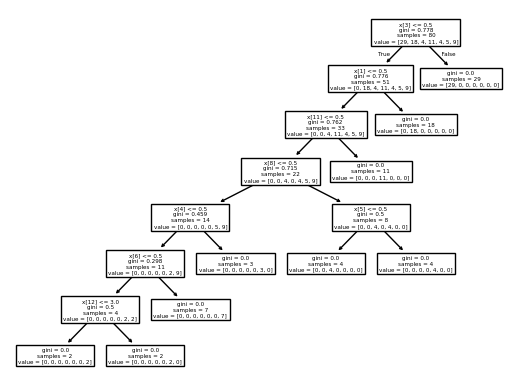

In [269]:
from sklearn.tree import plot_tree

_ = plot_tree(models[0]['model'])

### Que.5

In Churn.csv dataset you have to predict that customer is exited or not based on various factors given in dataset.
Implement a Decision Tree, Random Forest model and calculate Accuracy by confusion matrix, Calculate accuracy score, precision score, recall score, f1 score.

### import required packages

In [294]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [295]:
df = pd.read_csv('./Churn.csv')
df.head(2)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0


### exploratory data analysis

In [296]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [297]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis =1 , inplace = True)

In [298]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 966.1 KB


In [299]:
from sklearn.preprocessing import LabelEncoder

geography_encoder = LabelEncoder()
geography_encoder.fit(df['Geography'])
df['Geography'] = geography_encoder.transform(df['Geography'])

gender_encoder = LabelEncoder()
gender_encoder.fit(df['Gender'])
df['Gender'] = gender_encoder.transform(df['Gender'])



In [300]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  int64  
 2   Gender           10000 non-null  int64  
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9)
memory usage: 859.5 KB


### split the data into x and y

In [301]:
x = df.drop('Exited', axis =1)
y = df['Exited']

In [302]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state = 42)

### model creation and training

In [303]:
def decision_tree():
    from sklearn.tree import DecisionTreeClassifier

    # create and train the model
    model = DecisionTreeClassifier(max_depth= 5)

    model.fit(x_train, y_train)

    return model

In [304]:
def random_forest():
    from sklearn.ensemble import RandomForestClassifier

    # create and train the model

    model = RandomForestClassifier(max_depth= 9, n_estimators= 10)

    model.fit(x_train, y_train)

    return model

### evaluate the models

In [305]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, name, x, y):

    y_pred = model.predict(x)

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    return name, accuracy, precision, recall, f1

In [306]:
models = [
    {"name": "Decision Tree", "model": decision_tree()},
    {"name": "Random Forest", "model": random_forest()}
]

In [307]:
metrics_train =[]

for model_info in models:
    status = evaluate_models(model_info['model'], model_info['name'], x_train, y_train)

    metrics_train.append(status)

metrics_train_df = pd.DataFrame(metrics_train, columns = ['Algorithm', 'Accuracy','Precision', 'Recall', 'F1 Score'])
metrics_train_df

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.858875,0.854163,0.858875,0.839205
1,Random Forest,0.884250,0.883548,0.884250,0.871810


In [308]:
metrics_test =[]

for model_info in models:
    status = evaluate_models(model_info['model'], model_info['name'], x_test, y_test)

    metrics_test.append(status)

metrics_test_df = pd.DataFrame(metrics_test, columns = ['Algorithm', 'Accuracy','Precision', 'Recall', 'F1 Score'])
metrics_test_df

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.8575,0.847735,0.8575,0.838901
1,Random Forest,0.8620,0.852041,0.8620,0.847398


### find the values of decision tree and RandomForest for hyper-parameter

In [290]:
from sklearn.model_selection import GridSearchCV
parameter = {
    "max_depth" : [4, 5,7,9]
}
grid_search = GridSearchCV(models[0]['model'], parameter)
grid_search.fit(x_train, y_train)
grid_search.best_params_

{'max_depth': 5}

In [293]:
from sklearn.model_selection import GridSearchCV
parameters = {
    "max_depth" : [4, 5,7,9],
    "n_estimators": [10,15,20]
}
grid_search = GridSearchCV(models[1]['model'], parameters)
grid_search.fit(x_train, y_train)
grid_search.best_params_

{'max_depth': 9, 'n_estimators': 10}

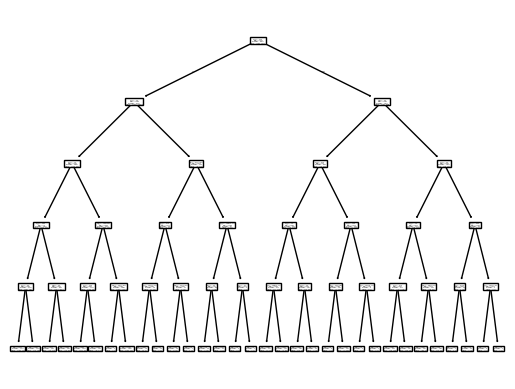

In [309]:
from sklearn.tree import plot_tree

_ = plot_tree(models[0]['model'])